# Fig: plot fixed points & sample path on phase plane
ISHII Hidemasa

In [1]:
using DifferentialEquations, Random
using CairoMakie
import ColorSchemes as cs

$$ \begin{aligned}
\dot{x}_1 =& f(x_1) + \frac{K}{2} (x_2 - x_1),  \\
\dot{x}_2 =& f(x_2) + \frac{K}{2} (x_1 - x_2).
\end{aligned} $$

In [2]:
f(x, r) = -x * (x - r) * (x - 1)

function twobox!(du, u, p, t)
    (; r, K) = p  # expand parameters
    du .= f.(u, r) .+ K / 2 * [u[2] - u[1]; u[1] - u[2]]
end

function noisecoef!(du, u, p, t)
    du .= p.σ
end

noisecoef! (generic function with 1 method)

## illustration with larger value of $r$

In [16]:
r = 0.3  # value for illustration!
D = 0.005
ξ = 0.5

0.5

In [17]:
Kvals = [0, 0.03, 0.1, 0.5]

4-element Vector{Float64}:
 0.0
 0.03
 0.1
 0.5

In [18]:
t_labhom = (:zz, :rr, :oo)
t_homfp = ([0, 0], [r, r], [1, 1])
t_labhet = (:zr, :zo, :rz, :ro, :oz, :or)
t_hetfp = ([0, r], [0, 1], [r, 0], [r, 1], [1, 0], [1, r])

function if_homfp(fp, mindist=1e-6, homfp=t_homfp)
    for hfp in homfp
        if sqrt(sum((hfp .- fp).^2)) < mindist
            return true
        end
    end
    return false
end

if_homfp (generic function with 3 methods)

In [19]:
# find fixed points
v_fpdict = [Dict{Symbol, Vector{Float64}}() for _ in 1:length(Kvals)]

# K = 0
for (lab, fp) in zip(t_labhom, t_homfp)
    v_fpdict[begin][lab] = fp
end
for (lab, fp) in zip(t_labhet, t_hetfp)
    v_fpdict[begin][lab] = fp
end

# K > 0
for (j, K) in enumerate(Kvals)
    if j == 1 continue end
    p = (; r=r, K=K)

    for (lab, fp0) in zip(t_labhet, t_hetfp)
        ssprob = SteadyStateProblem(twobox!, fp0, p)
        sol = solve(ssprob, SSRootfind())
        if !if_homfp(sol.u)
            # heterogeneous fixed point
            v_fpdict[j][lab] = sol.u
        end
    end
end

In [20]:
# obtain sample paths
v_traj = Vector{Vector{Vector{Float64}}}(undef, length(Kvals))
seed = 1028

for (j, K) in enumerate(Kvals)
    p = (; r=r, K=K, σ=sqrt(2D))
    sdeprob = SDEProblem(twobox!, noisecoef!, zeros(2), (0, 180), p, saveat=0.1, seed=seed)
    sol = solve(sdeprob, SOSRA(), abstol=5e-4, reltol=5e-3)
    v_traj[j] = [[u[1] for u in sol.u], [u[2] for u in sol.u]]
end

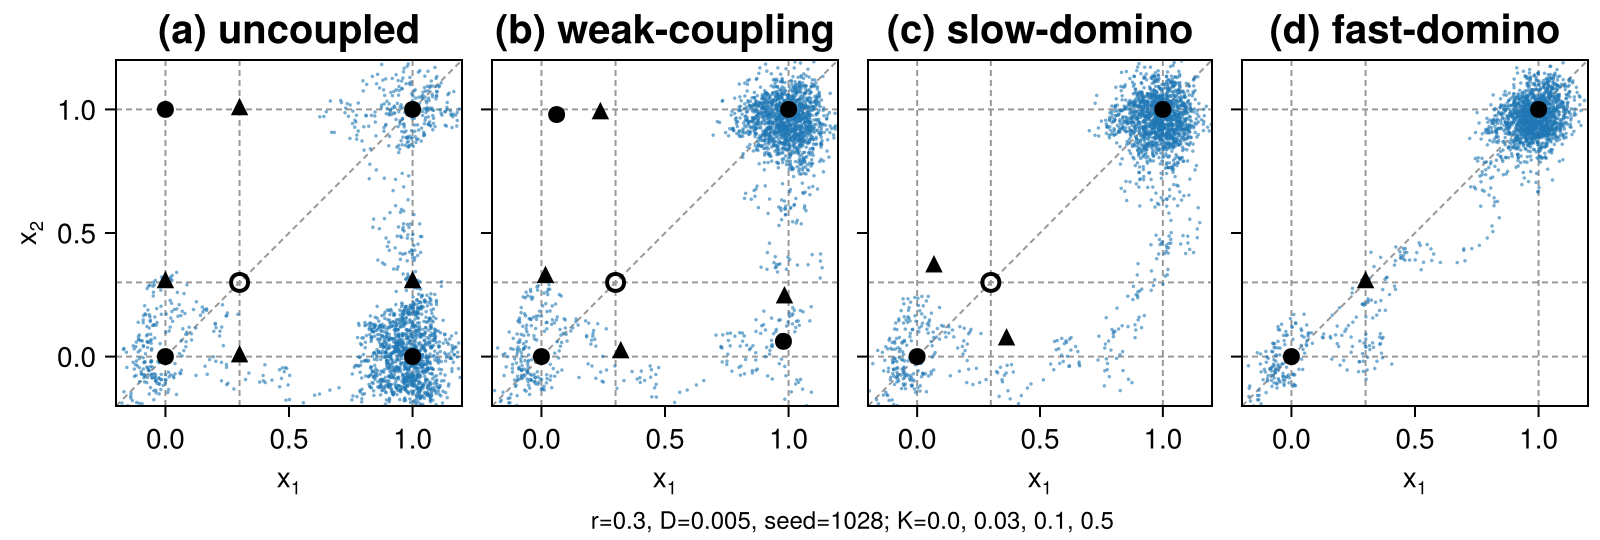

In [43]:
let ifsave=true
    fig = Figure(size=(800, 270), figure_padding=3,)
    axopts = (
        titlesize=20,
        xlabel=rich("x", subscript("1")), 
        xgridvisible=false, ygridvisible=false,
        aspect=DataAspect(), limits=(-0.2, 1.2, -0.2, 1.2),
    )
    ax1 = Axis(fig[1, 1]; ylabel=rich("x", subscript("2")), axopts...)
    ax2 = Axis(fig[1, 2]; yticklabelsvisible=false, axopts...)
    ax3 = Axis(fig[1, 3]; yticklabelsvisible=false, axopts...)
    ax4 = Axis(fig[1, 4]; yticklabelsvisible=false, axopts...)
    axes = [ax1, ax2, ax3, ax4]

    d_marker = Dict(:sink=>:circle, :saddle=>:utriangle, :source=>:circle)
    t_lab = ("a", "b", "c", "d")
    t_title = ("uncoupled", "weak-coupling", "slow-domino", "fast-domino")
    
    for (j, (ax, lab, title, K, fpdict, traj)) in enumerate(
        zip(axes, t_lab, t_title, Kvals, v_fpdict, v_traj)
    )
        colsize!(fig.layout, j, Aspect(1, 1))
        ax.title = "($lab) $title"

        # lines
        lineopts = (color=:gray60, linewidth=1, linestyle=(:dash, :dense))
        vlines!(ax, [0, r, 1]; lineopts...)
        hlines!(ax, [0, r, 1]; lineopts...)
        lines!(ax, [-0.3, 1.3], [-0.3, 1.3]; lineopts...)

        # trajectory
        scatter!(ax, traj[1], traj[2], markersize=2.5, color=(cs.tab10[1], 0.6))

        # fixed points
        ms = 12
        col = :black

        # sink
        sinkopts = (marker=d_marker[:sink], markersize=ms, color=col,)
        scatter!(ax, [0, 1], [0, 1]; sinkopts...)
        for lab in (:oz, :zo)
            if haskey(fpdict, lab)
                fp = fpdict[lab]
                scatter!(ax, fp[1], fp[2]; sinkopts...)
            end
        end

        # source
        if K < r * (1 - r)
            # before pitchfork of (r, r)
            scatter!(ax, [r], [r]; marker=d_marker[:source], markersize=ms, 
                color=(:white, 0), strokewidth=2, strokecolor=col,
            )
        end

        # saddle
        saddleopts = (marker=d_marker[:saddle], markersize=ms, color=col)
        if K >= r * (1 - r)
            # after pitchfork of (r, r)
            scatter!(ax, [r], [r]; saddleopts...)
        end
        for lab in (:zr, :rz, :ro, :or)
            if haskey(fpdict, lab)
                fp = fpdict[lab]
                scatter!(ax, fp[1], fp[2]; saddleopts...)
            end
        end
    end
    Label(fig[2, 1:4], "r=$r, D=$D, seed=$seed; K=$(join(Kvals, ", "))", tellwidth=false, fontsize=12,)
    rowgap!(fig.layout, 5)
    colgap!(fig.layout, 10)

    if ifsave save("output/fig-twobox-phaseplane-r03.pdf", fig) end
    display(fig)
end;